In [1]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from collections import defaultdict
import pandas as pd
import re
import random
from sklearn.metrics import f1_score, classification_report, brier_score_loss
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from src.data import load_and_prepare_datasets
from src.utils import load_finetuning_model
from src.finetuning.prediction import predict_with_scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
model, tokenizer = load_finetuning_model("models/finetuning_baseline/best", device=device)
model.eval()

[INFO] Loading finetuning model from: models/finetuning_baseline/best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] Finetuning model loaded successfully.


DistilBERTClassifier(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1)

In [3]:
datasets, id2label = load_and_prepare_datasets(
    tokenizer=tokenizer,
)
 
test_set = datasets["test"]
print("Lenght of the test set:", len(test_set))

Jigsaw dataset already exists. Skipping download.


Map:   0%|          | 0/129251 [00:00<?, ? examples/s]

Map:   0%|          | 0/14362 [00:00<?, ? examples/s]

Map:   0%|          | 0/15958 [00:00<?, ? examples/s]

Lenght of the test set: 15958


In [8]:
i = 4
sample = test_set[i]
 
text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
label = sample["labels"]

print("======== EXAMPLE =========")
 
print("TEXT:", text)
print("TRUE LABELS:", label.numpy())
print("CLASS NAMES:", id2label)

print("\n MODEL PREDICTIONS:")

result = predict_with_scores(model, tokenizer, text, id2label, device="cuda")
for label, result in result["active_labels"]:
        print(f"{label:15s} | result: {result}")

print("=========================")

======== EXAMPLE =========
TEXT: fuck you wanker
TRUE LABELS: [1. 1. 1. 0. 1. 0.]
CLASS NAMES: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

 MODEL PREDICTIONS:
obscene         | result: 0.9999325275421143
toxic           | result: 0.999474823474884
insult          | result: 0.9941791296005249
severe_toxic    | result: 0.962758481502533


In [15]:
combos = defaultdict(list)

for i, sample in tqdm.tqdm(enumerate(test_set)):
    labels = tuple(int(x) for x in sample["labels"].numpy())
    text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

    result = predict_with_scores(
        model=model,
        tokenizer=tokenizer,
        text=text,
        id2label=id2label,
        device=device,
        threshold=0.5,
        top_k=3,
    )

    # probs y stds por label
    predictions = np.array([p for _, p  in result["raw_probs"]])

    pred_labels = (predictions >= 0.5).astype(int)
    correct = np.array_equal(np.array(labels), pred_labels)


    combos[labels].append({
        "index": i,
        "text": text,
        "combo_true": labels,
        "combo_pred": tuple(pred_labels.tolist()),
        "correct": correct,
        "probs": predictions.tolist(),
    })

15958it [02:17, 115.77it/s]


In [16]:
all_samples = []
for combo_list in combos.values():
    all_samples.extend(combo_list)

corrects      = np.array([x['correct']     for x in all_samples]).astype(int)

num_labels = len(all_samples[0]['probs'])
y_true = np.array([x['combo_true'] for x in all_samples])
y_pred = np.array([x['combo_pred'] for x in all_samples])

print(f'Test samples: {len(all_samples):,}')


Test samples: 15,958


Global exact-match accuracy: 0.9229

  Label           | Accuracy |       F1 | Brier Score
  --------------------------------------
  toxic           |   0.9653 |   0.8107 |   0.0347
  severe_toxic    |   0.9895 |   0.4732 |   0.0105
  obscene         |   0.9789 |   0.8117 |   0.0211
  threat          |   0.9962 |   0.4505 |   0.0038
  insult          |   0.9763 |   0.7617 |   0.0237
  identity_hate   |   0.9924 |   0.5399 |   0.0076
  --------------------------------------
  F1-micro        |          |   0.7685
  F1-macro        |          |   0.6413
  Brier score     |          |   0.1013


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


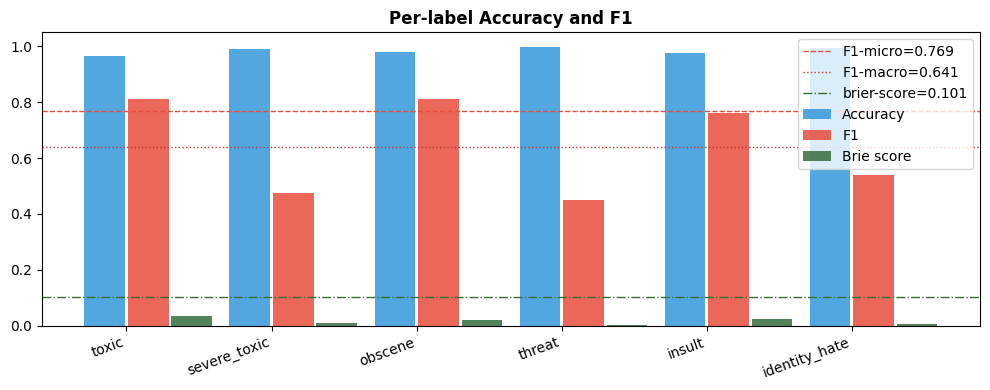

In [17]:
# Global exact-match accuracy
accuracy = corrects.mean()
print(f'Global exact-match accuracy: {accuracy:.4f}\n')

# Per-label accuracy and F1
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
accs = [(y_true[:,i] == y_pred[:,i]).mean() for i in range(num_labels)]
f1s  = [f1_score(y_true[:,i], y_pred[:,i], zero_division=0) for i in range(num_labels)]
brier_scores  = [brier_score_loss(y_true[:,i], y_pred[:,i]) for i in range(num_labels)]

f1_micro = f1_score(y_true, y_pred, average='micro',  zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro',  zero_division=0)
brier_score = brier_score_loss(y_true, y_pred)

print(f'  {"Label":15s} | {"Accuracy":>8s} | {"F1":>8s} | {"Brier Score":>8s}')
print('  ' + '-'*38)
for lbl, acc, f1, bs in zip(label_cols, accs, f1s, brier_scores):
    print(f'  {lbl:15s} | {acc:>8.4f} | {f1:>8.4f} | {bs:>8.4f}')
print('  ' + '-'*38)
print(f'  {"F1-micro":15s} | {" ":>8s} | {f1_micro:>8.4f}')
print(f'  {"F1-macro":15s} | {" ":>8s} | {f1_macro:>8.4f}')
print(f'  {"Brier score":15s} | {" ":>8s} | {brier_score:>8.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(num_labels)
ax.bar(x - 0.15, accs, 0.28, label='Accuracy', color='#3498db', alpha=0.85)
ax.bar(x + 0.15, f1s,  0.28, label='F1',       color='#e74c3c', alpha=0.85)
ax.bar(x + 0.45, brier_scores,  0.28, label='Brie score',       color="#366c40", alpha=0.85)
ax.axhline(f1_micro, linestyle='--', color='#e74c3c', linewidth=1, label=f'F1-micro={f1_micro:.3f}')
ax.axhline(f1_macro, linestyle=':',  color='#c0392b', linewidth=1, label=f'F1-macro={f1_macro:.3f}')
ax.axhline(brier_score, linestyle='dashdot',  color="#396b32", linewidth=1, label=f'brier-score={brier_score:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Per-label Accuracy and F1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


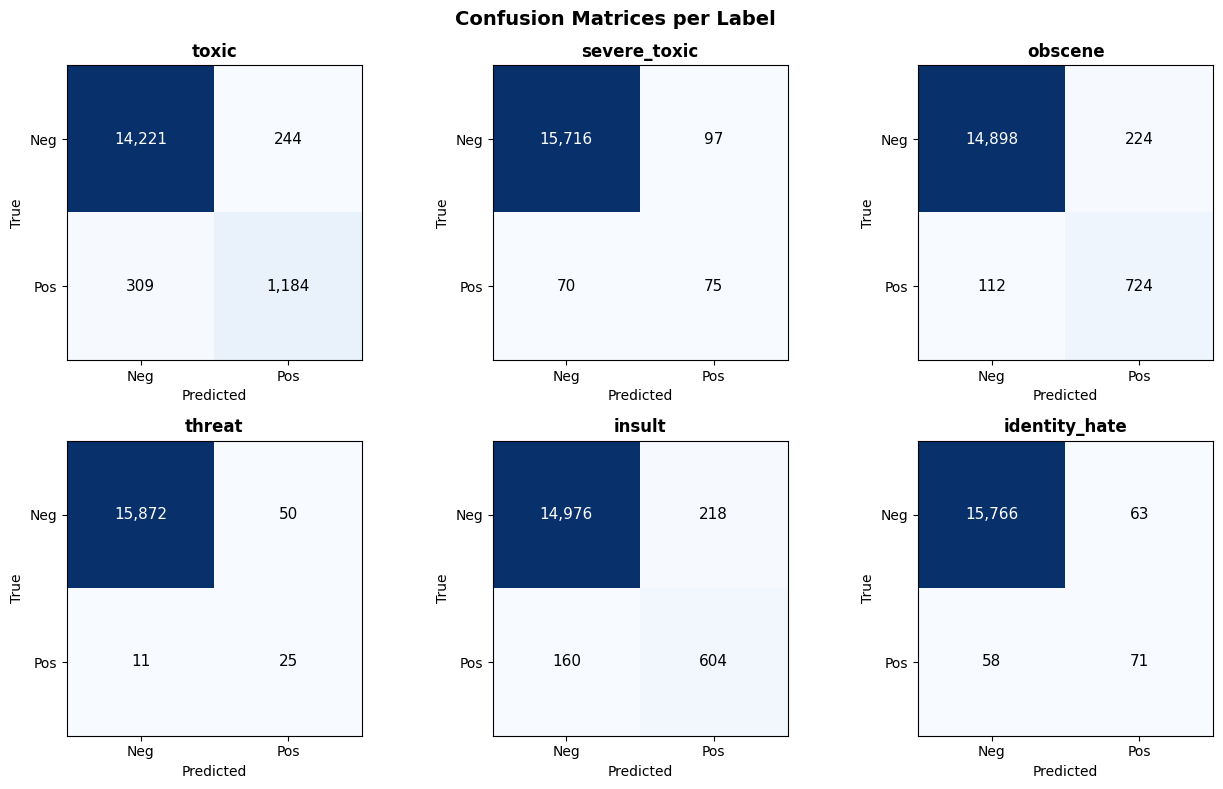

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (lbl, ax) in enumerate(zip(label_cols, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    im = ax.imshow(cm, cmap='Blues')
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm[r,c]:,}', ha='center', va='center',
                    color='white' if cm[r,c] > cm.max()/2 else 'black', fontsize=11)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg','Pos']); ax.set_yticklabels(['Neg','Pos'])

plt.suptitle('Confusion Matrices per Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [19]:
def leet_speak(text):
    """Replace letters with visually similar digits (l33tspeak)."""
    return text.translate(str.maketrans('aeiost', '431057'))

def add_spaces(text):
    """Insert spaces between every character of long words."""
    return ' '.join(' '.join(w) if len(w) > 4 else w for w in text.split())

def unicode_homoglyphs(text):
    """Replace Latin letters with visually identical Cyrillic characters."""
    return text.translate(str.maketrans('aeoi', 'аеоі'))

def add_typos(text, rate=0.12, seed=42):
    """Randomly duplicate or drop characters."""
    rng, result = random.Random(seed), []
    for c in text:
        r = rng.random()
        if   r < rate/2:  pass
        elif r < rate:    result.extend([c, c])
        else:             result.append(c)
    return ''.join(result)

def punct_noise(text):
    """Intercalate dots between pairs of word characters."""
    return re.sub(r'(\w)(\w)', r'\1.\2', text)

def neutral_prefix(text):
    """Prepend an innocuous phrase to dilute toxicity signal."""
    return 'In my humble opinion, ' + text

TRANSFORMS = {
    'original':          lambda x: x,
    'leet_speak':        leet_speak,
    'add_spaces':        add_spaces,
    'unicode_homoglyphs':unicode_homoglyphs,
    'typos':             add_typos,
    'punct_noise':       punct_noise,
    'neutral_prefix':    neutral_prefix,
}
print('Perturbation functions:', list(TRANSFORMS.keys()))


Perturbation functions: ['original', 'leet_speak', 'add_spaces', 'unicode_homoglyphs', 'typos', 'punct_noise', 'neutral_prefix']


In [39]:
import os
path = "top2_uncertain_per_combo_unfreezed.json"
with open(path, "r", encoding="utf-8") as f:
    top2_uncertain_per_combo = json.load(f)

adv_corpus = []
for combo, samples in top2_uncertain_per_combo.items():
    for s in samples:
        adv_corpus.append({
            'text':        s['text'],
            'true_labels': s['combo_true'],
            'orig_preds':  s['combo_pred'],
            'orig_unc':    s['uncertainty'],
            'orig_correct':s['correct'],
            'combo':       combo,
        })

print(f'Adversarial corpus: {len(adv_corpus)} samples')
print(f'  Covering {len(top2_uncertain_per_combo)} label combinations')
print(f'  Mean baseline uncertainty: {np.mean([s["orig_unc"] for s in adv_corpus]):.4f}')
print(f'  Baseline accuracy on these samples: {np.mean([s["orig_correct"] for s in adv_corpus]):.4f}')


Adversarial corpus: 51 samples
  Covering 29 label combinations
  Mean baseline uncertainty: 0.3017
  Baseline accuracy on these samples: 0.1373


In [43]:
adv_results = []  # one entry per corpus sample

for entry in tqdm.tqdm(adv_corpus):
    row = {
        'combo':      entry['combo'],
        'text':       entry['text'],
        'true_labels':entry['true_labels'],
        'orig_preds': entry['orig_preds'],
        'orig_unc':   entry['orig_unc'],
        'orig_correct':entry['orig_correct'],
        'variants':   [],
    }

    for t_name, t_fn in TRANSFORMS.items():
        if t_name == 'original':
            # We already have the original prediction — reuse it
            row['variants'].append({
                'transform':   'original',
                'text':        entry['text'],
                'preds':       list(entry['orig_preds']),
                'uncertainty': entry['orig_unc'],
                'flipped':     False,
                'correct':     entry['orig_correct'],
            })
            continue

        perturbed = t_fn(entry['text'])
        result    = predict_with_scores(
            model=model, tokenizer=tokenizer, text=perturbed,
            id2label=id2label, device=device, threshold=0.5, top_k=3)

        probs = np.array([p for _,p in result['raw_probs']])
        preds = (probs >= 0.5).astype(int).tolist()


        row['variants'].append({
            'transform':   t_name,
            'text':        perturbed,
            'probs':       probs.tolist(),
            'preds':       preds,
            'flipped':     preds != list(entry['orig_preds']),
            'correct':     bool(np.array_equal(preds, list(entry['true_labels']))),

        })

    adv_results.append(row)

print(f'Done. {len(adv_results)} samples evaluated.')


100%|██████████| 51/51 [00:02<00:00, 19.73it/s]

Done. 51 samples evaluated.


  Transform                 |  Flip rate |  Mean Δunc |   Accuracy
  ----------------------------------------------------------------
  leet_speak                |     92.2%  |       +nan |     0.0392
  add_spaces                |     78.4%  |       +nan |     0.0588
  unicode_homoglyphs        |     94.1%  |       +nan |     0.0392
  typos                     |     68.6%  |       +nan |     0.1176
  punct_noise               |     96.1%  |       +nan |     0.0196
  neutral_prefix            |     66.7%  |       +nan |     0.1765


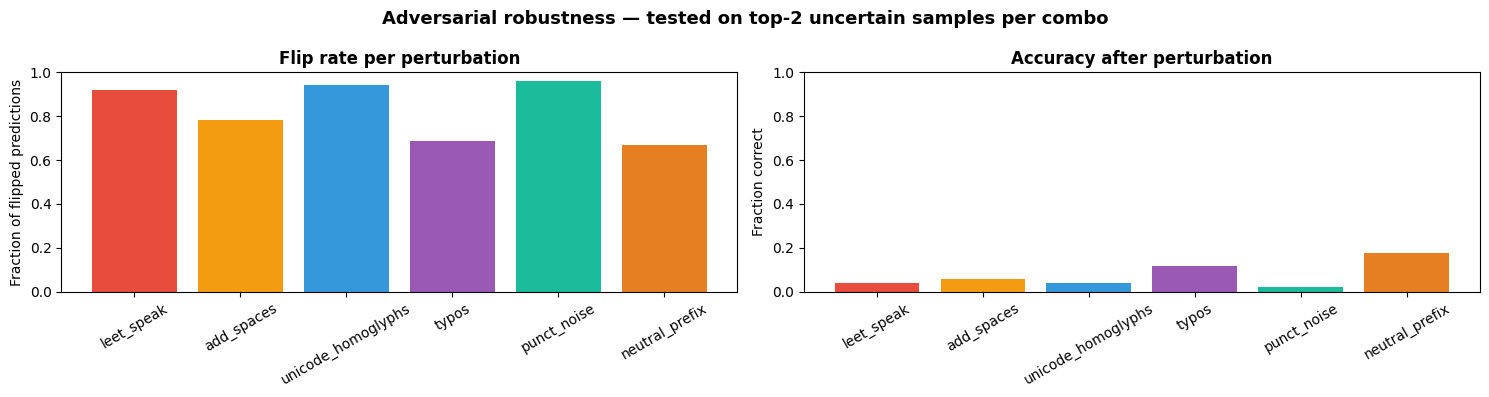

In [47]:
transform_names = [t for t in TRANSFORMS.keys() if t != 'original']

summary = {}
for t_name in transform_names:
    flips, delta_uncs, accs = [], [], []
    for row in adv_results:
        v = next(x for x in row['variants'] if x['transform'] == t_name)
        flips.append(int(v['flipped']))
        accs.append(int(v['correct']))
    summary[t_name] = {
        'flip_rate': np.mean(flips),
        'mean_delta_unc': np.mean(delta_uncs),
        'accuracy': np.mean(accs),
    }

print(f'  {"Transform":25s} | {"Flip rate":>10s} | {"Mean Δunc":>10s} | {"Accuracy":>10s}')
print('  ' + '-'*64)
for t, s in summary.items():
    print(f'  {t:25s} | {s["flip_rate"]:>9.1%}  | {s["mean_delta_unc"]:>+10.4f} | {s["accuracy"]:>10.4f}')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
t_labels = list(summary.keys())
colors   = ['#e74c3c','#f39c12','#3498db','#9b59b6','#1abc9c','#e67e22']

axes[0].bar(t_labels, [summary[t]['flip_rate']      for t in t_labels], color=colors)
axes[0].set_title('Flip rate per perturbation', fontweight='bold')
axes[0].set_ylabel('Fraction of flipped predictions')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)


axes[1].bar(t_labels, [summary[t]['accuracy']       for t in t_labels], color=colors)
axes[1].set_title('Accuracy after perturbation', fontweight='bold')
axes[1].set_ylabel('Fraction correct')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Adversarial robustness — tested on top-2 uncertain samples per combo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
